<a href="https://colab.research.google.com/github/lakshmivalsalan/machine-learning-fundamentals/blob/main/Predict_customerChurn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ML: TASK-05**

# **Customer Churn Prediction**

### Load and Inspect Data

In [ ]:
import pandas as pd

# loading the dataset
df = pd.read_csv('Churn_Modelling.csv')


In [ ]:
# gives the number of rows and columns
df.shape

(10000, 14)

In [ ]:
# returns the data-types, non-null counts, column-names
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# gives summary statistics for numerical columns
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### Data Preprocessing

Handling Missing values

In [ ]:
df.isnull().sum()
print("\n Total Missing Values:", df.isnull().sum().sum())


 Total Missing Values: 0


The dataset contains no missing values across 14 columns, so no imputation was required.

### Encode categorical features

In [ ]:
df.nunique()

,0
RowNumber,10000
CustomerId,10000
Surname,2932
CreditScore,460
Geography,3
Gender,2
Age,70
Tenure,11
Balance,6382
NumOfProducts,4


nunique() returns the count of distinct values in each column, which helps to identify which columns are categorical.

Geography (3 unique values) and Gender (2 unique values) have very few distinct values and are stored as text (object dtype), confirming they are categorical features that need to be encoded before they can be used in a machine learning model.

HasCrCard, IsActiveMember, and Exited also show only 2 unique values each. Although these columns are stored as numeric (int64), their low unique-value count shows they behave as categorical flags (0/1) rather than continuous numeric values. Since they are already represented numerically, no further encoding is needed for them. Exited is the target variable, not an input feature.


Conclusion: Based on this analysis, Geography and Gender are the only two columns that require categorical encoding.





### Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# One-Hot Encoding
df = pd.get_dummies(df, columns=['Geography'], drop_first=True, dtype=int)

df.head()


,RowNumber,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,1,15634602,Hargrave,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,2,15647311,Hill,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,3,15619304,Onio,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,4,15701354,Boni,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,5,15737888,Mitchell,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


Gender was encoded using LabelEncoding since it only has two categories (Male/Female). With just two classes, assigning 0/1 doesn't introduce any false or ordinal relationship. There is no "in-between" value that could mislead the model.

Geography was encoded using One-Hot-Encoding since it has three nominal categories (France,Germany,Spain) with no natural ordering between them.Label encoding would have implied a ranking, which doesn't reflect reality.One-Hot Encoding avoid this by creating a separate binary column for each category.

### **Scaling Numerical Features using StandardScaler**

In [ ]:
from sklearn.preprocessing import StandardScaler

numerical_cols = ['CreditScore', 'Age','Tenure','Balance', 'NumOfProducts', 'EstimatedSalary']

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])


In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,1,15634602,Hargrave,-0.326221,0,0.293517,-1.041760,-1.225848,-0.911583,1,1,0.021886,1,0,0
1,2,15647311,Hill,-0.440036,0,0.198164,-1.387538,0.117350,-0.911583,0,1,0.216534,0,0,1
2,3,15619304,Onio,-1.536794,0,0.293517,1.032908,1.333053,2.527057,1,0,0.240687,1,0,0
3,4,15701354,Boni,0.501521,0,0.007457,-1.387538,-1.225848,0.807737,0,0,-0.108918,0,0,0
4,5,15737888,Mitchell,2.063884,0,0.388871,-1.041760,0.785728,-0.911583,1,1,-0.365276,0,0,1


### **Model Training**

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df.drop(['Exited', 'RowNumber', 'CustomerId', 'Surname'], axis=1)
Y = df['Exited']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# train SVM with different kernels
kernels = ['linear', 'rbf']
results = {}

for k in kernels:
  model = SVC(kernel=k, random_state=42)
  model.fit(X_train, Y_train)
  Y_pred = model.predict(X_test)

  cm = confusion_matrix(Y_test, Y_pred)
  print("Confusion Matrix:")
  print(cm)

  acc = accuracy_score(Y_test, Y_pred)
  results[k] = acc

  print(f"\n ---- Kernel: {k} ----")
  print(f"\nAccuracy: {acc:.4f}")
  print(classification_report(Y_test, Y_pred))
  print()

print("Summary:", results)

Confusion Matrix:
[[1593    0]
 [ 407    0]]

 ---- Kernel: linear ----

Accuracy: 0.7965
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1593
           1       0.00      0.00      0.00       407

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.63      0.80      0.71      2000


Confusion Matrix:
[[1566   27]
 [ 241  166]]

 ---- Kernel: rbf ----

Accuracy: 0.8660
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1593
           1       0.86      0.41      0.55       407

    accuracy                           0.87      2000
   macro avg       0.86      0.70      0.74      2000
weighted avg       0.87      0.87      0.85      2000


Summary: {'linear': 0.7965, 'rbf': 0.866}


### **Observation**

The SVM model was tested with both linear and RBF kernels to compare performance on the Churn Modelling dataset.

The **linear kernel** achieved an accuracy of 0.7965, but this is misleading. It failed to correctly identify any churned customers which belong to class 1 — precision, recall, and f1-score for class 1 are all 0.00, which means the model simply predicted "not churned" for nearly every customer. The high accuracy comes only from the class imbalance (around 80% of customers did not churn), not from any real learning. This indicates the relationship between the features and churn is not linearly separable.

The **RBF kernel** performed noticeably better, with an accuracy of 0.8660. More importantly, it achieved a precision of 0.86 and recall of 0.41 for class 1, meaning it was actually able to detect a meaningful portion of churned customers while keeping false positives low. The macro average f1-score also improved from 0.44 (linear) to 0.74 (RBF), confirming that RBF handles both classes far more effectively.

### **Train the KNN model**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, Y_train)
Y_pred = knn.predict(X_test)

cm = confusion_matrix(Y_test, Y_pred)
print("Confusion Matrix:")
print(cm)

print("\nAccuracy:", accuracy_score(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))

Confusion Matrix:
[[1514   79]
 [ 236  171]]

Accuracy: 0.8425
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      1593
           1       0.68      0.42      0.52       407

    accuracy                           0.84      2000
   macro avg       0.77      0.69      0.71      2000
weighted avg       0.83      0.84      0.83      2000



### **Elbow Method for KNN**

To determine whether a different value of K would improve performance, the Elbow Method was applied by training KNN models for K values ranging from 1 to 20 and recording the error rate for each.

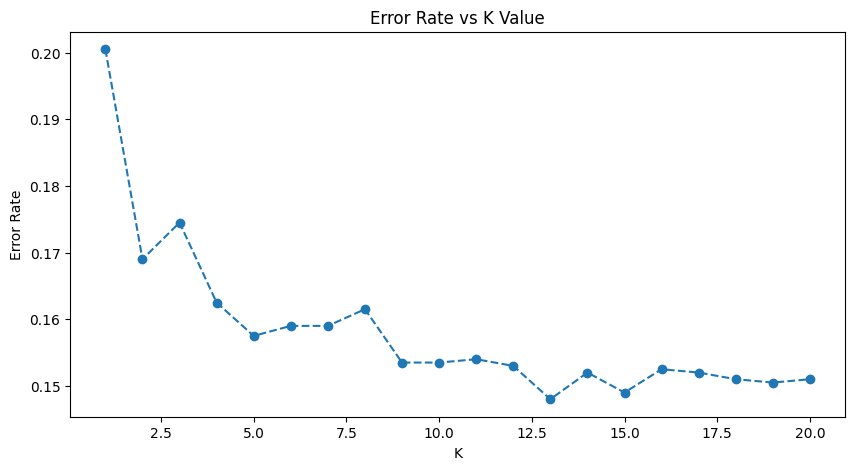

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# list to store the error rate for each value of K
error_rate = []

# try K values from 1 to 20
for i in range (1,21):
  knn = KNeighborsClassifier(n_neighbors=i)

  # train the model on the training data
  knn.fit(X_train, Y_train)


  # predict on the test data using this K
  pred_i = knn.predict(X_test)

  # calculate error rate
  error_rate.append(np.mean(pred_i != Y_test))

# plot K values against their error rates
plt.figure(figsize=(10,5))
plt.plot(range(1,21), error_rate, marker='o',linestyle='dashed')
plt.title('Error Rate vs K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()







The error rate started high at K=1 (~0.20) and dropped sharply through K=2 to K=5, after which it flattened out, fluctuating mildly between 0.15 and 0.16 for the remaining K values up to 20. The "elbow" — the point where the steep decline transitions into a flat trend — occurs around K=5.

Therefore, K=5 was chosen as a suitable value for this dataset, consistent with the initial baseline model.



### **Model Comparison**

Comparing SVM (linear, rbf) and KNN together across all evaluation metrics:

SVM with linear kernel performs the worst overall. Its confusion matrix is **[[1593, 0], [407, 0]]** — it predicted every customer as "not churned," correctly classifying all 1593 actual non-churned customers but wrongly classifying all 407 actual churned customers as well. This is reflected directly in its metrics: precision, recall, and f1-score for class 1 are all 0.00, since the model never predicted class 1 even once. The accuracy of **0.7965** looks decent on the surface, but it's misleading — it's only that high because the majority class dominates the dataset, not because the model learned anything about churn.

SVM with rbf kernel performs the best overall. Its confusion matrix is **[[1566, 27], [241, 166]]**— 1566 not-churned customers were correctly identified with only 27 false positives, and 166 churned customers were correctly caught while 241 were missed. This balance shows up clearly in its metrics: the low false positives (27) give it a high precision for class 1 (0.86), while the higher false negatives (241) keep its recall comparatively lower (0.41). Its overall accuracy (**0.8660**) and macro avg f1-score (0.74) are also the highest among all three models, confirming it handles both classes more reliably than the others.

KNN sits in between the two SVM kernels. Its confusion matrix is **[[1514, 79], [236, 171]]** — it correctly classified 1514 not-churned customers but had more false positives (79) than rbf, and caught slightly more churners (171) while missing slightly fewer (236) compared to rbf. This is why KNN's recall (0.42) is marginally higher than rbf's (0.41), but its precision (0.68) is noticeably lower than rbf's (0.86), since it makes more false-positive errors overall. Its accuracy (**0.8425**) and macro avg f1-score (0.71) both fall between linear and rbf.




Based on everything compared so far — confusion matrix, accuracy, precision, recall, and f1-score, the **best-performing classifier** is the **SVM with RBF kernel.**

Highest accuracy **(0.8660)** among the three models compared (Linear: 0.7965, KNN: 0.8425).

Lowest false positive count **(27, vs KNN's 79)** — meaning it rarely wrongly flags loyal customers as churn risks.

Highest precision for class 1 **(0.86 vs KNN's 0.68)** — when it predicts churn, it's right most of the time.

Highest macro avg f1-score **(0.74 vs KNN's 0.71) **— better overall balance across both classes, not just the majority one.

SVM with Linear kernel is ruled out entirely, since it never predicts the churned class at all (0 precision, recall, f1 for class 1) — making it unusable for this task despite a deceptively okay-looking accuracy.
So between RBF and KNN, RBF wins on every metric except recall, where the two are nearly tied. That makes** SVM (RBF kernel) the best-performing classifier** for this churn dataset, among the models evaluated.



### **Conclusion**

**SVM with Linear kernel**

Strengths: It's computationally simple and fast to train compared to non-linear kernels. Its accuracy (0.7965) looks reasonable at first glance, and it doesn't make any false positive errors.

Weaknesses: This model completely fails to detect the churned class. Its confusion matrix [[1593, 0], [407, 0]] shows it predicted every single customer as "not churned," missing all 407 actual churners. Precision, recall, and f1-score for class 1 are all 0.00.

Suitability: Not suitable for this task. Since churn is the class we actually care about predicting, a model that never identifies a single churner is unusable here — regardless of its accuracy score.






**SVM with RBF kernel**

Strengths: This is the best-performing model overall. It has the highest accuracy (0.8660), the highest precision for class 1 (0.86), and the lowest false positive count (27) among the models compared. It rarely wrongly flags loyal customers as churners, which is valuable if false alarms are costly.

Weaknesses: Its recall for class 1 (0.41) is still relatively low — it misses 241 out of 407 actual churners. So while it's precise when it does predict churn, it's still letting more than half of real churners slip through undetected.

Suitability: Best suited among the three if the priority is minimizing false alarms while still catching a reasonable number of churners.







**KNN**

Strengths: Its recall for class 1 (0.42) is marginally the highest among the three models, meaning it catches slightly more actual churners than RBF (171 vs 166). It's also simple to understand and implement, with the Elbow Method giving a clear way to tune k.

Weaknesses: It has a high false positive count (79), nearly 3x more than RBF's 27, which drags down both its precision (0.68) and overall accuracy (0.8425).

Suitability: Reasonable as a backup model, but not ideal if false positives carry a real cost.







Overall, SVM with RBF kernel is the most suitable model for this churn dataset, since it balances accuracy, precision, and recall better than the other two. KNN comes second, offering a fractionally higher recall at the cost of many more false positives. SVM with Linear kernel is unsuitable entirely, as it fails to identify the churned class altogether.